# 📈 Lab 5: Regression Analysis
### DATA.110 - Introduction to Python Programming for Machine Learning
---
**Objective:** Understand, implement, and evaluate regression models — starting from simple linear regression through multiple linear regression and polynomial regression.

**Topics Covered:**
- Simple Linear Regression (from scratch + scikit-learn)
- Multiple Linear Regression
- Polynomial Regression
- Model Evaluation Metrics (MSE, RMSE, MAE, R²)
- Train/Test Split & Cross Validation
- Feature Scaling
- Residual Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
np.random.seed(42)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Understanding Linear Regression

**Simple Linear Regression** models the relationship between two continuous variables:

$$\hat{y} = \beta_0 + \beta_1 x$$

- $\beta_0$ = intercept (y when x=0)
- $\beta_1$ = slope (change in y per unit increase in x)

The goal is to minimize the **Sum of Squared Errors (SSE)**:
$$SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

## 2. Simple Linear Regression — From Scratch

Intercept (β₀): 48.2000
Slope     (β₁): 4.3818
Equation: score = 48.20 + 4.38 × hours


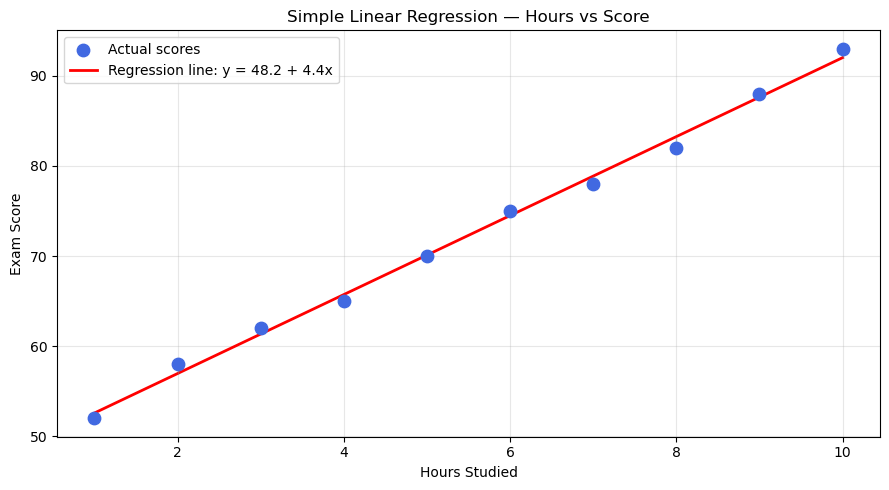

In [2]:
def linear_regression_scratch(x, y):
    """Compute slope and intercept using Ordinary Least Squares."""
    n = len(x)
    x_mean, y_mean = np.mean(x), np.mean(y)
    
    numerator   = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sum((x - x_mean) ** 2)
    
    slope     = numerator / denominator
    intercept = y_mean - slope * x_mean
    return slope, intercept


# Dataset: Hours Studied vs Exam Score
hours   = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
scores  = np.array([52, 58, 62, 65, 70, 75, 78, 82, 88, 93])

slope, intercept = linear_regression_scratch(hours, scores)
print(f"Intercept (β₀): {intercept:.4f}")
print(f"Slope     (β₁): {slope:.4f}")
print(f"Equation: score = {intercept:.2f} + {slope:.2f} × hours")

# Predictions
y_pred = intercept + slope * hours

# Plot
plt.figure(figsize=(9, 5))
plt.scatter(hours, scores, color='royalblue', s=80, label='Actual scores', zorder=5)
plt.plot(hours, y_pred, color='red', linewidth=2, label=f'Regression line: y = {intercept:.1f} + {slope:.1f}x')
for xi, yi, yhi in zip(hours, scores, y_pred):
    plt.vlines(xi, yhi, yi, colors='gray', linewidth=1, linestyles='dashed', alpha=0.5)
plt.xlabel('Hours Studied'); plt.ylabel('Exam Score')
plt.title('Simple Linear Regression — Hours vs Score')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 3. Evaluation Metrics

In [3]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"  MSE  (Mean Squared Error):     {mse:.4f}")
    print(f"  RMSE (Root MSE):               {rmse:.4f}")
    print(f"  MAE  (Mean Absolute Error):    {mae:.4f}")
    print(f"  R²   (Coefficient of Determ.): {r2:.4f} ({r2*100:.1f}% variance explained)")
    return {'MSE':mse, 'RMSE':rmse, 'MAE':mae, 'R2':r2}

metrics_scratch = evaluate_model(scores, y_pred, "Scratch Linear Regression")

--- Scratch Linear Regression ---
  MSE  (Mean Squared Error):     0.6073
  RMSE (Root MSE):               0.7793
  MAE  (Mean Absolute Error):    0.7091
  R²   (Coefficient of Determ.): 0.9962 (99.6% variance explained)


## 4. Simple Linear Regression with Scikit-Learn

In [4]:
X = hours.reshape(-1, 1)   # sklearn needs 2D X
y = scores

model = LinearRegression()
model.fit(X, y)

print(f"sklearn β₀ (intercept): {model.intercept_:.4f}")
print(f"sklearn β₁ (slope):     {model.coef_[0]:.4f}")

# Predict for new values
new_hours = np.array([[3.5], [7.5], [11]])
new_preds = model.predict(new_hours)
print("\nPredictions for new hours:")
for h, p in zip(new_hours.flatten(), new_preds):
    print(f"  {h} hours → predicted score: {p:.1f}")

y_pred_sk = model.predict(X)
evaluate_model(y, y_pred_sk, "sklearn LinearRegression")

sklearn β₀ (intercept): 48.2000
sklearn β₁ (slope):     4.3818

Predictions for new hours:
  3.5 hours → predicted score: 63.5
  7.5 hours → predicted score: 81.1
  11.0 hours → predicted score: 96.4
--- sklearn LinearRegression ---
  MSE  (Mean Squared Error):     0.6073
  RMSE (Root MSE):               0.7793
  MAE  (Mean Absolute Error):    0.7091
  R²   (Coefficient of Determ.): 0.9962 (99.6% variance explained)


{'MSE': 0.6072727272727269,
 'RMSE': np.float64(0.7792770542449757),
 'MAE': 0.7090909090909101,
 'R2': 0.9961809148652744}

## 5. Multiple Linear Regression

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

In [5]:
# Simulated housing dataset
np.random.seed(42)
n = 200

sqft       = np.random.randint(800, 3500, n)          # square footage
bedrooms   = np.random.randint(1, 6, n)               # num bedrooms
age        = np.random.randint(1, 50, n)              # house age
garage     = np.random.choice([0, 1], n, p=[0.3,0.7]) # has garage
school_dist = np.random.uniform(0.5, 10, n)           # miles to school

# True relationship with noise
price = (150 * sqft 
         + 8000 * bedrooms 
         - 1200 * age 
         + 15000 * garage 
         - 5000 * school_dist 
         + 50000
         + np.random.normal(0, 20000, n))

# DataFrame
house_df = pd.DataFrame({
    'SqFt': sqft, 'Bedrooms': bedrooms, 'Age': age,
    'Garage': garage, 'SchoolDist': school_dist, 'Price': price
})
print("Housing Dataset (first 5 rows):")
print(house_df.head())
print(f"\nShape: {house_df.shape}")
house_df.describe().round(1)

Housing Dataset (first 5 rows):
   SqFt  Bedrooms  Age  Garage  SchoolDist          Price
0  1660         4   16       1    7.581675  286594.744587
1  2094         3   39       0    4.600766  321396.904026
2  1930         3    5       1    1.712013  415338.472411
3  1895         1   22       0    3.195871  277728.555383
4  2438         5   29       1    3.949282  443925.236302

Shape: (200, 6)


,SqFt,Bedrooms,Age,Garage,SchoolDist,Price
count,200.0,200.0,200.0,200.0,200.0,200.0
mean,2225.0,2.9,25.4,0.7,5.2,358368.0
std,728.9,1.4,13.8,0.5,2.7,116185.4
min,801.0,1.0,1.0,0.0,0.5,118279.7
25%,1644.2,2.0,13.0,0.0,2.8,272053.0
50%,2278.5,3.0,26.0,1.0,5.3,354833.1
75%,2838.8,4.0,36.0,1.0,7.6,452841.9
max,3495.0,5.0,49.0,1.0,10.0,596495.3


In [6]:
# Train / Test Split
feature_cols = ['SqFt','Bedrooms','Age','Garage','SchoolDist']
X_multi = house_df[feature_cols]
y_multi = house_df['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Fit model
mlr = LinearRegression()
mlr.fit(X_train, y_train)

# Coefficients
print("\nModel Coefficients:")
print(f"  Intercept: ${mlr.intercept_:,.0f}")
for feat, coef in zip(feature_cols, mlr.coef_):
    print(f"  {feat:<12}: ${coef:>10,.2f}")

# Evaluate
y_pred_train = mlr.predict(X_train)
y_pred_test  = mlr.predict(X_test)
print()
evaluate_model(y_train, y_pred_train, "Multiple LR — Train")
print()
evaluate_model(y_test,  y_pred_test,  "Multiple LR — Test")

Training samples: 160
Testing samples:  40

Model Coefficients:
  Intercept: $40,646
  SqFt        : $    151.92
  Bedrooms    : $  8,011.93
  Age         : $ -1,086.86
  Garage      : $ 15,999.76
  SchoolDist  : $ -5,084.78

--- Multiple LR — Train ---
  MSE  (Mean Squared Error):     408314483.6276
  RMSE (Root MSE):               20206.7930
  MAE  (Mean Absolute Error):    16189.2184
  R²   (Coefficient of Determ.): 0.9717 (97.2% variance explained)

--- Multiple LR — Test ---
  MSE  (Mean Squared Error):     524260532.8215
  RMSE (Root MSE):               22896.7363
  MAE  (Mean Absolute Error):    19949.4337
  R²   (Coefficient of Determ.): 0.9442 (94.4% variance explained)


{'MSE': 524260532.8215359,
 'RMSE': np.float64(22896.73629191584),
 'MAE': 19949.433672483006,
 'R2': 0.9442055345269402}

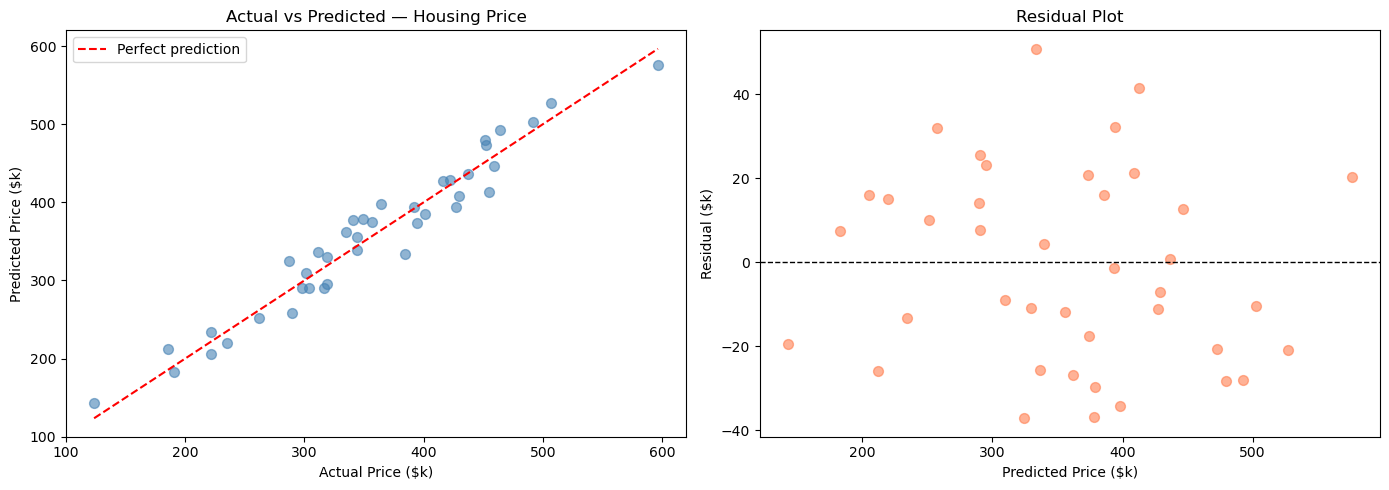

In [7]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test/1e3, y_pred_test/1e3, alpha=0.6, color='steelblue', s=50)
mn, mx = y_test.min()/1e3, y_test.max()/1e3
axes[0].plot([mn,mx],[mn,mx],'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual Price ($k)'); axes[0].set_ylabel('Predicted Price ($k)')
axes[0].set_title('Actual vs Predicted — Housing Price')
axes[0].legend()

# Residuals
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test/1e3, residuals/1e3, alpha=0.6, color='coral', s=50)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted Price ($k)'); axes[1].set_ylabel('Residual ($k)')
axes[1].set_title('Residual Plot')

plt.tight_layout(); plt.show()

## 6. Polynomial Regression
For nonlinear relationships, we expand features with polynomial terms.

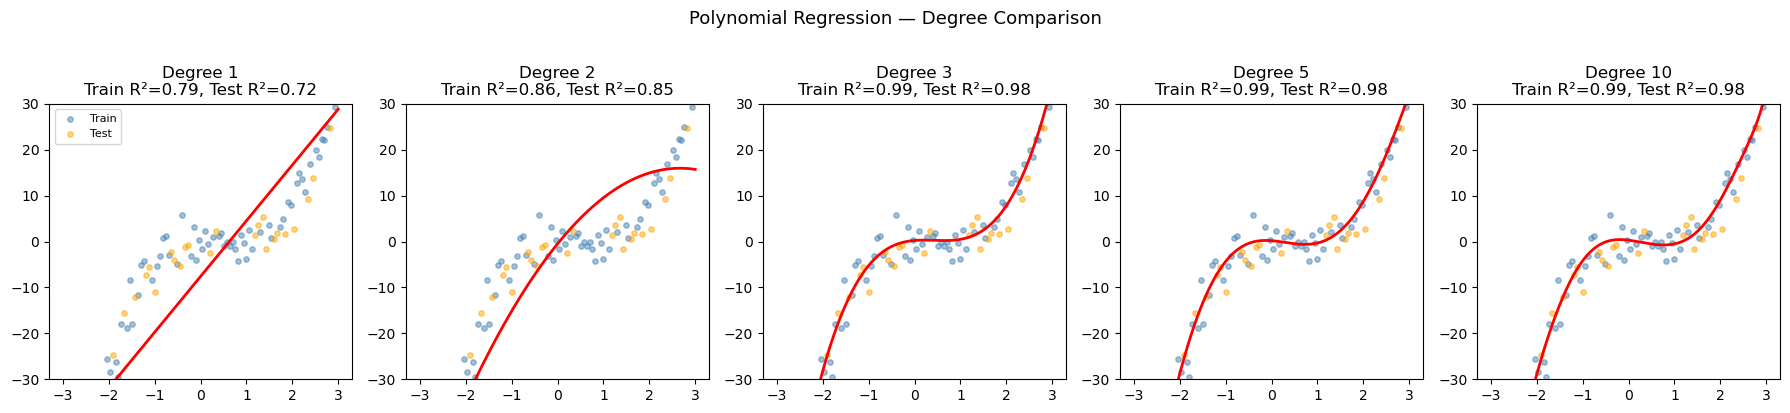


R² by degree:
 degree  train_r2  test_r2
      1  0.785504 0.722426
      2  0.858701 0.846794
      3  0.986234 0.984457
      5  0.987300 0.980450
     10  0.987465 0.978981


In [8]:
# Nonlinear data
np.random.seed(0)
x_poly = np.linspace(-3, 3, 100)
y_true = 2*x_poly**3 - 3*x_poly**2 + x_poly + 1
y_noisy = y_true + np.random.normal(0, 3, len(x_poly))

X_p = x_poly.reshape(-1, 1)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_p, y_noisy, test_size=0.3, random_state=42)

degrees = [1, 2, 3, 5, 10]
x_plot = np.linspace(-3, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, len(degrees), figsize=(18, 4))
results = []

for ax, deg in zip(axes, degrees):
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('scaler', StandardScaler()),
        ('linreg', LinearRegression())
    ])
    pipe.fit(X_train_p, y_train_p)
    
    train_r2 = r2_score(y_train_p, pipe.predict(X_train_p))
    test_r2  = r2_score(y_test_p,  pipe.predict(X_test_p))
    results.append({'degree':deg, 'train_r2':train_r2, 'test_r2':test_r2})
    
    ax.scatter(X_train_p, y_train_p, alpha=0.5, s=15, color='steelblue', label='Train')
    ax.scatter(X_test_p,  y_test_p,  alpha=0.5, s=15, color='orange',   label='Test')
    ax.plot(x_plot, pipe.predict(x_plot), color='red', linewidth=2)
    ax.set_title(f'Degree {deg}\nTrain R²={train_r2:.2f}, Test R²={test_r2:.2f}')
    ax.set_ylim(-30, 30)
    if deg == 1:
        ax.legend(fontsize=8)

plt.suptitle('Polynomial Regression — Degree Comparison', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("\nR² by degree:")
print(pd.DataFrame(results).to_string(index=False))

## 7. Ridge and Lasso Regularization
Regularization adds a penalty term to prevent overfitting.

In [9]:
from sklearn.linear_model import Ridge, Lasso

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

models = {
    'Linear (no reg)': LinearRegression(),
    'Ridge (α=1.0)':   Ridge(alpha=1.0),
    'Ridge (α=10.0)':  Ridge(alpha=10.0),
    'Lasso (α=0.1)':   Lasso(alpha=0.1),
    'Lasso (α=1.0)':   Lasso(alpha=1.0)
}

print(f"{'Model':<22} {'Train R²':>10} {'Test R²':>10} {'Test RMSE':>12}")
print("-" * 56)

for name, m in models.items():
    m.fit(X_train_scaled, y_train)
    tr_r2  = r2_score(y_train, m.predict(X_train_scaled))
    te_r2  = r2_score(y_test,  m.predict(X_test_scaled))
    te_rmse= np.sqrt(mean_squared_error(y_test, m.predict(X_test_scaled)))
    print(f"{name:<22} {tr_r2:>10.4f} {te_r2:>10.4f} {te_rmse:>12,.0f}")

Model                    Train R²    Test R²    Test RMSE
--------------------------------------------------------
Linear (no reg)            0.9717     0.9442       22,897
Ridge (α=1.0)              0.9717     0.9446       22,815
Ridge (α=10.0)             0.9684     0.9448       22,773
Lasso (α=0.1)              0.9717     0.9442       22,897
Lasso (α=1.0)              0.9717     0.9442       22,896


## 8. Cross-Validation

In [10]:
# 5-fold cross validation
cv_model = LinearRegression()
cv_scores = cross_val_score(cv_model, X_multi, y_multi, cv=5, scoring='r2')

print("5-Fold Cross-Validation R² scores:")
for fold, score in enumerate(cv_scores, 1):
    bar = '█' * int(score * 20)
    print(f"  Fold {fold}: {score:.4f}  {bar}")
print(f"\nMean R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold Cross-Validation R² scores:
  Fold 1: 0.9672  ███████████████████
  Fold 2: 0.9576  ███████████████████
  Fold 3: 0.9733  ███████████████████
  Fold 4: 0.9647  ███████████████████
  Fold 5: 0.9625  ███████████████████

Mean R²: 0.9651 ± 0.0052


## 9. Feature Importance (Correlation Analysis)

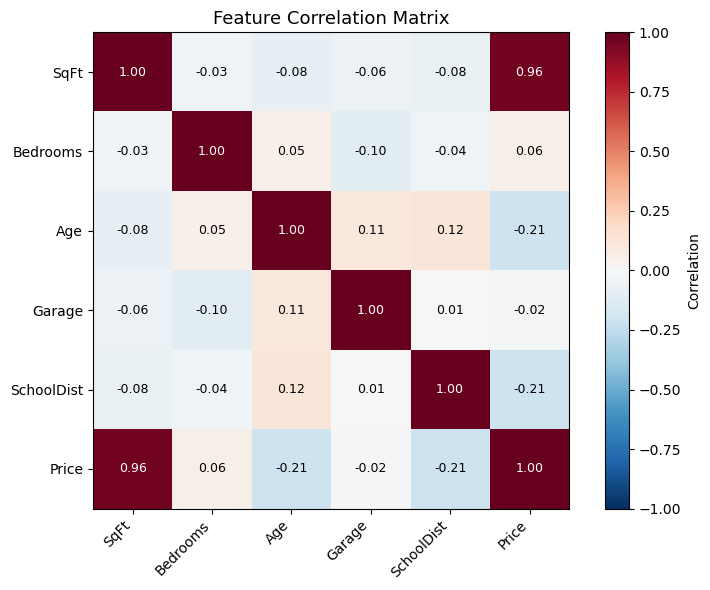

Correlations with Price:
Price         1.000
SqFt          0.962
Bedrooms      0.058
Garage       -0.022
SchoolDist   -0.206
Age          -0.206
Name: Price, dtype: float64


In [11]:
# Correlation heatmap
import matplotlib.colors as mcolors

corr = house_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Correlation')

cols = corr.columns.tolist()
ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)

ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout(); plt.show()

print("Correlations with Price:")
print(house_df.corr()['Price'].sort_values(ascending=False).round(3))

## Summary

| Model | Description | Key Parameter |
|---|---|---|
| Simple Linear Regression | One predictor | `LinearRegression()` |
| Multiple Linear Regression | Multiple predictors | `LinearRegression()` |
| Polynomial Regression | Nonlinear via feature expansion | `PolynomialFeatures(degree)` |
| Ridge Regression | L2 regularization | `Ridge(alpha)` |
| Lasso Regression | L1 regularization (feature selection) | `Lasso(alpha)` |

| Metric | Formula | Interpretation |
|---|---|---|
| MSE | $\frac{1}{n}\sum(y-\hat{y})^2$ | Lower is better |
| RMSE | $\sqrt{MSE}$ | Same units as y |
| MAE | $\frac{1}{n}\sum|y-\hat{y}|$ | Robust to outliers |
| R² | $1 - \frac{SS_{res}}{SS_{tot}}$ | 1.0 = perfect |

---
✅ **Lab 5 Complete**